# 01 — Memahami dataset ROBOD

5 ruangan gedung SDE4 NUS (Singapura), interval 5 menit, 7 Sep–23 Des 2021, hanya hari kerja. Notebook ini menjawab: apa isi datanya, bagaimana ruangan berbeda, dan apakah energi HVAC bereaksi terhadap okupansi.

Prasyarat: `SupplementaryData.zip` sudah di-unzip ke `data/raw/`.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():          # notebook dijalankan dari notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aiobep.data import FEATURES, ROOM_INFO, load_rooms
from zipfile import ZipFile

out = ROOT / "outputs" / "eda"
out.mkdir(parents=True, exist_ok=True)
raw_dir = ROOT / "data" / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

zip_candidates = [
    ROOT / "SupplementaryData.zip",
    ROOT / "data" / "SupplementaryData.zip",
    raw_dir / "SupplementaryData.zip",
]

zip_path = next((p for p in zip_candidates if p.exists()), None)

room_csvs = [raw_dir / f"combined_Room{i}.csv" for i in range(1, 6)]
if not all(p.exists() for p in room_csvs):
    if zip_path is None:
        raise FileNotFoundError(
            f"Data CSV files not found in {raw_dir} and no SupplementaryData.zip was found. "
            f"Please unzip SupplementaryData.zip into {raw_dir}."
        )

    print(f"Extracting {zip_path.name} to {raw_dir} ...")
    with ZipFile(zip_path, "r") as z:
        z.extractall(raw_dir)

if not all(p.exists() for p in room_csvs):
    missing = [str(p.name) for p in room_csvs if not p.exists()]
    raise FileNotFoundError(
        f"Missing room CSV files after extraction: {missing}. "
        f"Please unzip SupplementaryData.zip into {raw_dir}."
    )

df = load_rooms()

FileNotFoundError: C:\dari D\UNNES\Semester 6\AI-OBEP\ai-obep\data\raw\combined_Room1.csv not found - unzip SupplementaryData.zip into C:\dari D\UNNES\Semester 6\AI-OBEP\ai-obep\data\raw

## 1. Ringkasan per ruangan
`hvac_Wh_m2_per_day` = energi HVAC (ceiling fan + chilled water + fan AHU/FCU) per m² per hari. Kolom AHU/VAV kosong 100% di R1/R2 karena memang memakai FCU (bukan data hilang).

In [ ]:
g = df.groupby("room")
ov = pd.DataFrame({
    "name": [ROOM_INFO[r]["name"] for r in g.groups],
    "hvac": [ROOM_INFO[r]["hvac"] for r in g.groups],
    "area_m2": [ROOM_INFO[r]["area"] for r in g.groups],
    "days": g.day.nunique(), "rows": g.size(),
    # persen NaN pada kolom yang memang dimiliki ruangan itu
    "missing_%": (g.apply(lambda d: d.dropna(axis=1, how="all").isna().mean().mean()) * 100).round(2),
    "occ_mean": g.occupant_count.mean().round(2), "occ_max": g.occupant_count.max(),
    "present_%": (g.occupant_presence.mean() * 100).round(1),
    "T_mean_C": g.air_temperature.mean().round(2), "RH_mean_%": g.indoor_relative_humidity.mean().round(1),
    "hvac_kWh_per_day": g.apply(lambda d: d.hvac_energy_wh_m2.sum() * ROOM_INFO[d.name]["area"] / 1000 / d.day.nunique()).round(1),
    "hvac_Wh_m2_per_day": (g.hvac_energy_wh_m2.sum() / g.day.nunique()).round(1),
})
ov.to_csv(out / "room_overview.csv")
ov

,name,hvac,area_m2,days,rows,missing_%,occ_mean,occ_max,present_%,T_mean_C,RH_mean_%,hvac_kWh_per_day,hvac_Wh_m2_per_day
room,,,,,,,,,,,,,
1,Lecture room (large),FCU,118.6,29,8352,0.05,1.60,38,21.1,26.84,75.2,133.5,1125.6
2,Lecture room (small),FCU,53.7,29,8352,0.07,1.21,22,28.4,25.57,71.2,84.3,1569.6
3,Office (admin staff),AHU/VAV,98.4,29,8352,0.02,1.55,13,39.9,27.29,61.4,34.5,350.3
4,Office (researchers),AHU/VAV,141.9,47,13536,0.01,3.33,18,65.1,27.41,73.1,93.7,660.0
5,Library,AHU/VAV,182.8,47,13536,0.95,1.87,16,42.5,28.18,62.6,247.3,1352.9


## 2. Profil harian: okupansi vs energi HVAC
Band abu-abu = jadwal HVAC 08:30–18:40. Okupansi mengikuti orang; HVAC mengikuti jadwal.

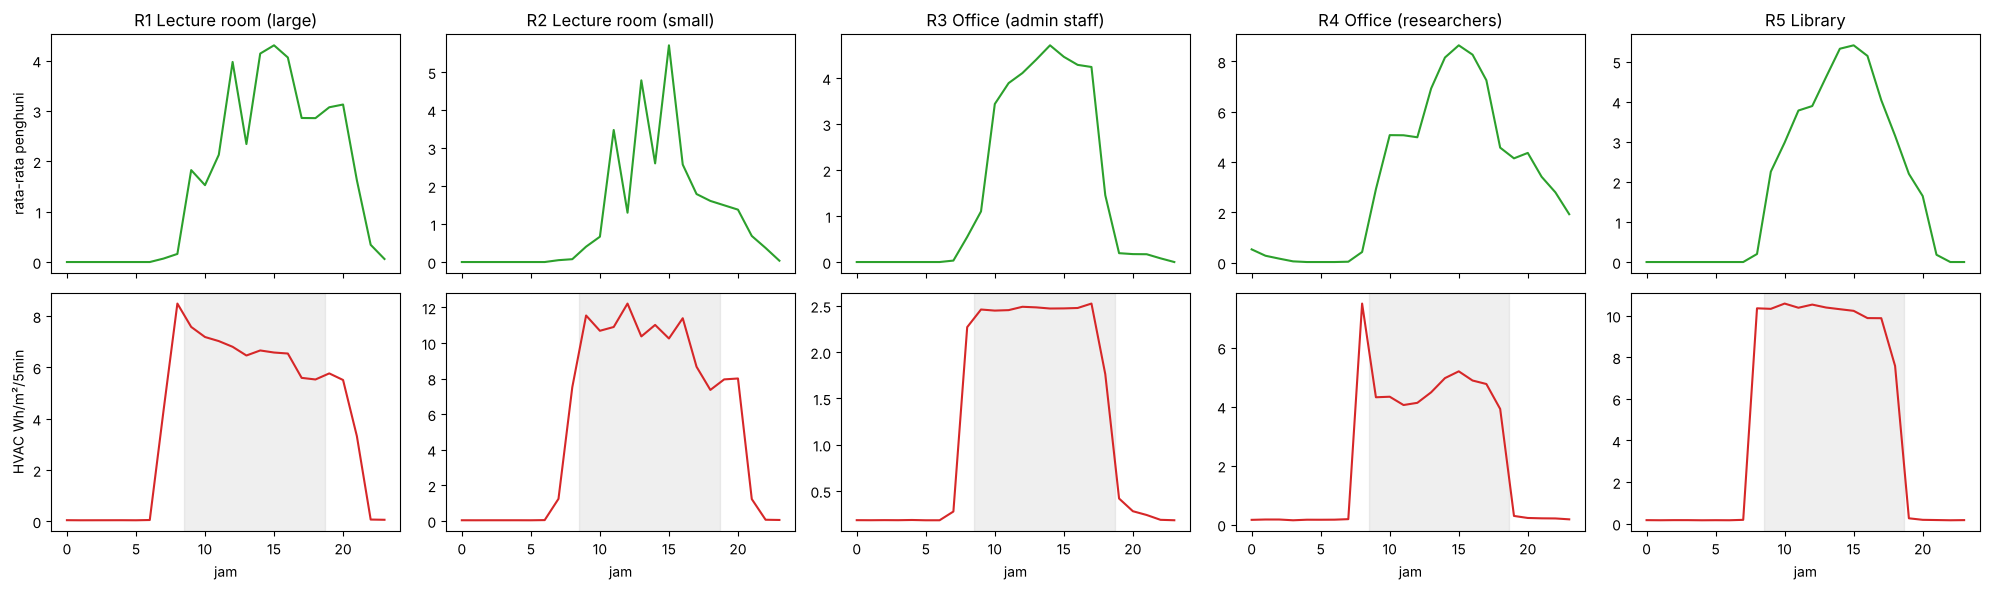

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(20, 6), sharex=True)
for i, r in enumerate(range(1, 6)):
    d = df[df.room == r]
    prof = d.groupby(d.ts.dt.hour)[["occupant_count", "hvac_energy_wh_m2"]].mean()
    ax[0, i].plot(prof.index, prof.occupant_count, c="tab:green"); ax[0, i].set_title(f"R{r} {ROOM_INFO[r]['name']}")
    ax[1, i].plot(prof.index, prof.hvac_energy_wh_m2, c="tab:red"); ax[1, i].set_xlabel("jam")
    ax[1, i].axvspan(8.5, 18.67, color="grey", alpha=.12)
ax[0, 0].set_ylabel("rata-rata penghuni"); ax[1, 0].set_ylabel("HVAC Wh/m²/5min")
plt.tight_layout(); plt.savefig(out / "daily_profiles.png", dpi=120); plt.show()

## 3. Apakah energi bereaksi terhadap okupansi *di dalam jam operasional*?
Korelasi Spearman energi vs okupansi / suhu luar / radiasi surya, hanya jam operasional.

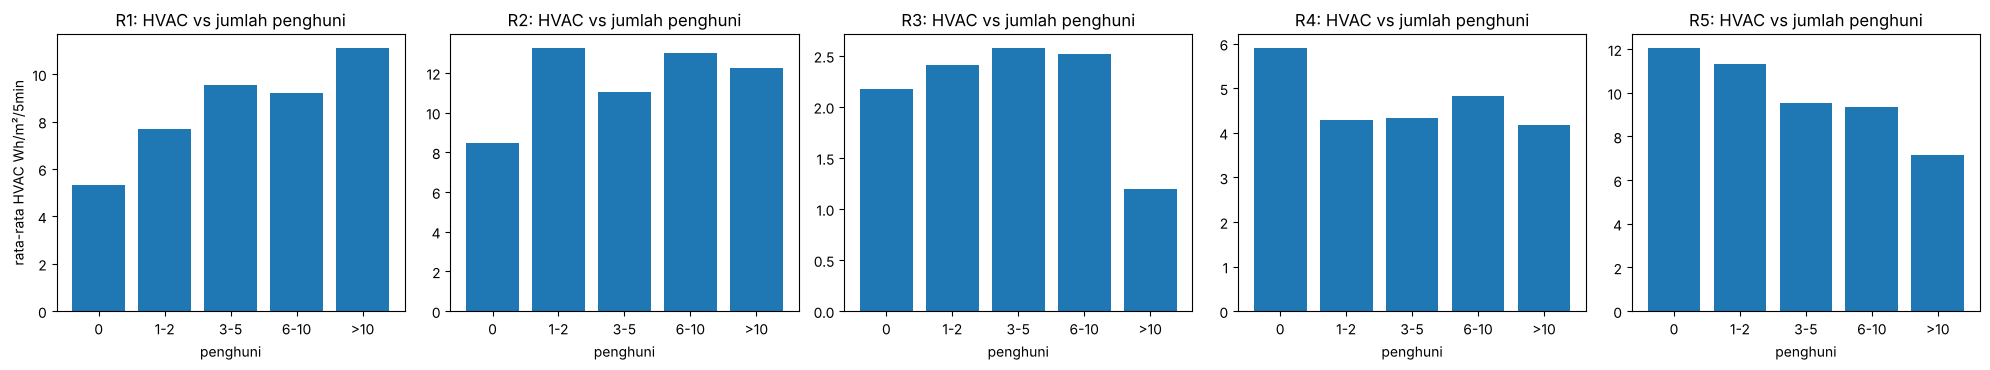

,room,spearman_occ,spearman_outdoorT,spearman_solar
0,1,0.45,-0.13,-0.02
1,2,0.25,0.01,0.05
2,3,0.12,-0.03,0.13
3,4,0.07,0.19,0.04
4,5,-0.19,0.18,0.05


In [ ]:
op = df[df.is_operating].dropna(subset=["hvac_energy_wh_m2", "occupant_count"])
fig, ax = plt.subplots(1, 5, figsize=(20, 3.8))
rows = []
for i, r in enumerate(range(1, 6)):
    d = op[op.room == r]
    bins = pd.cut(d.occupant_count, [-1, 0, 2, 5, 10, 100], labels=["0", "1-2", "3-5", "6-10", ">10"])
    m = d.groupby(bins, observed=True).hvac_energy_wh_m2.mean()
    ax[i].bar(m.index.astype(str), m.values); ax[i].set_title(f"R{r}: HVAC vs jumlah penghuni"); ax[i].set_xlabel("penghuni")
    rows.append(dict(room=r,
                     spearman_occ=d.occupant_count.corr(d.hvac_energy_wh_m2, method="spearman"),
                     spearman_outdoorT=d.dry_bulb_temp.corr(d.hvac_energy_wh_m2, method="spearman"),
                     spearman_solar=d.global_horizontal_solar_radiation.corr(d.hvac_energy_wh_m2, method="spearman")))
ax[0].set_ylabel("rata-rata HVAC Wh/m²/5min")
plt.tight_layout(); plt.savefig(out / "energy_vs_occupancy_operating_hours.png", dpi=120); plt.show()
corr = pd.DataFrame(rows).round(2); corr.to_csv(out / "operating_hours_correlations.csv", index=False); corr

**Temuan:** korelasi lemah (≈0,07–0,12 di kantor, negatif di perpustakaan) → HVAC saat ini tidak responsif terhadap okupansi. Inilah celah AI-OBEP.

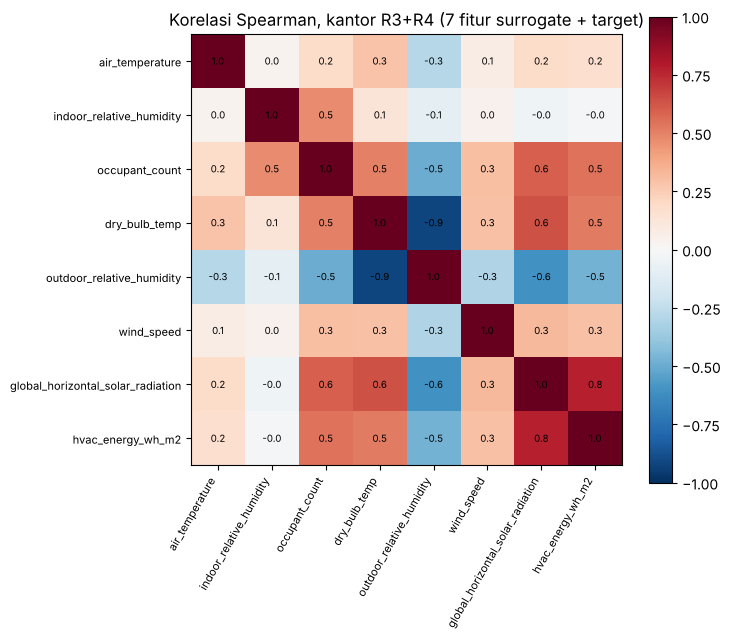

In [ ]:
offc = df[df.room.isin([3, 4])].dropna(subset=FEATURES + ["hvac_energy_wh_m2"])
C = offc[FEATURES + ["hvac_energy_wh_m2"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.columns, fontsize=8)
for i in range(len(C)):
    for j in range(len(C)):
        ax.text(j, i, f"{C.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); ax.set_title("Korelasi Spearman, kantor R3+R4 (7 fitur surrogate + target)")
plt.tight_layout(); plt.savefig(out / "feature_correlation.png", dpi=120); plt.show()

## 4. Data hilang

In [ ]:
miss = df.groupby("room").apply(lambda d: d.isna().mean() * 100).T
miss = miss[(miss > 0).any(axis=1)].round(2)
miss.to_csv(out / "missing_pct_by_room.csv"); miss

room,1,2,3,4,5
voc,0.17,0.36,0.16,0.1,0.11
sound_pressure_level,0.17,0.36,0.16,0.1,0.11
indoor_relative_humidity,0.17,0.36,0.16,0.1,0.11
illuminance,0.17,0.36,0.16,0.1,0.11
pm2.5,0.17,0.36,0.16,0.1,0.11
indoor_co2,0.17,0.36,0.16,0.1,0.11
chilled_water_energy,0.12,0.00,0.00,0.0,0.00
fcu_fan_energy,0.12,0.00,100.00,100.0,100.00
fcu_fan_speed,0.11,0.00,100.00,100.0,100.00
supply_air_pressure,0.11,0.00,0.00,0.0,0.00


## 5. Sensor murah sebagai proxy okupansi (relevan untuk lapisan edge)
Korelasi Pearson dengan jumlah penghuni sebenarnya (kamera).

In [ ]:
sens = df.dropna(subset=["indoor_co2", "wifi_connected_devices", "occupant_count"])
sc = pd.DataFrame([dict(room=r, corr_co2=d.indoor_co2.corr(d.occupant_count),
                        corr_wifi=d.wifi_connected_devices.corr(d.occupant_count),
                        corr_sound=d.sound_pressure_level.corr(d.occupant_count))
                   for r, d in sens.groupby("room")]).round(2)
sc.to_csv(out / "occupancy_proxy_correlations.csv", index=False); sc

,room,corr_co2,corr_wifi,corr_sound
0,1,0.32,0.89,-0.02
1,2,-0.01,0.74,-0.12
2,3,0.11,0.52,-0.22
3,4,0.40,0.57,-0.09
4,5,0.53,0.62,-0.28


## 6. Satu minggu di Ruang 4

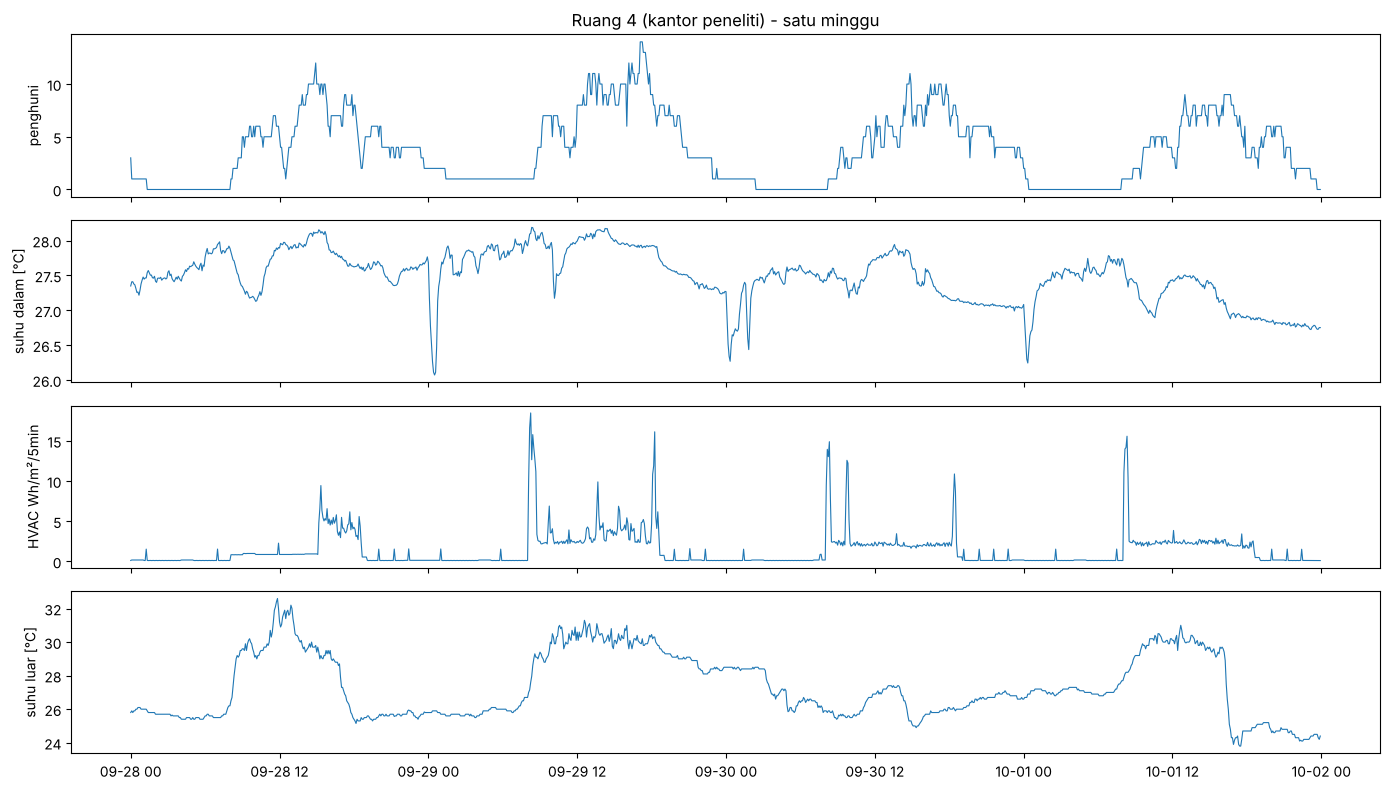

In [ ]:
d = df[df.room == 4]
wk = d[(d.ts >= d.ts.min() + pd.Timedelta(days=21)) & (d.ts < d.ts.min() + pd.Timedelta(days=28))]
fig, ax = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for a, (c, lab) in zip(ax, [("occupant_count", "penghuni"), ("air_temperature", "suhu dalam [°C]"),
                            ("hvac_energy_wh_m2", "HVAC Wh/m²/5min"), ("dry_bulb_temp", "suhu luar [°C]")]):
    a.plot(wk.ts, wk[c], lw=.8); a.set_ylabel(lab)
ax[0].set_title("Ruang 4 (kantor peneliti) - satu minggu")
plt.tight_layout(); plt.savefig(out / "room4_week.png", dpi=120); plt.show()